# MSCS-634 Project Deliverable 1: Data Collection, Cleaning, and Exploration
## Telco Customer Churn Dataset

**Course:** MSCS-634 — Advanced Big Data and Data Mining


## 1. Dataset Selection and Justification

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) (IBM sample dataset)




In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

#Download dataset and get path
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Path to dataset files:", path)

df = pd.read_csv(f'{path}/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1
(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Inspecting Structure

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [22]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning

### 3.1 Handling missing / inconsistent values


In [23]:
blank_mask = df['TotalCharges'].str.strip() == ''
print(f"Blank TotalCharges rows: {blank_mask.sum()}")
df.loc[blank_mask, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Blank TotalCharges rows: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [24]:
#Convert to numeric; blanks become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
#These 11 customers have tenure == 0, so TotalCharges is legitimately 0 (no billing history yet),
#not missing data to impute from other rows.
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(df['TotalCharges'].isnull().sum(), 'remaining nulls')
print(df.isnull().sum().sum(), 'total nulls in dataframe')

0 remaining nulls
0 total nulls in dataframe


### 3.2 Removing duplicates

In [25]:
print('Duplicate customerIDs:', df['customerID'].duplicated().sum())
print('Fully duplicate rows:', df.duplicated().sum())

Duplicate customerIDs: 0
Fully duplicate rows: 0


### 3.3 Identifying and addressing noisy / inconsistent data


In [26]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
cat_cols = df.select_dtypes(include='object').columns.drop('customerID')
for col in cat_cols:
    print(col, '->', df[col].unique())

gender -> ['Female' 'Male']
SeniorCitizen -> ['No' 'Yes']
Partner -> ['Yes' 'No']
Dependents -> ['No' 'Yes']
PhoneService -> ['No' 'Yes']
MultipleLines -> ['No phone service' 'No' 'Yes']
InternetService -> ['DSL' 'Fiber optic' 'No']
OnlineSecurity -> ['No' 'Yes' 'No internet service']
OnlineBackup -> ['Yes' 'No' 'No internet service']
DeviceProtection -> ['No' 'Yes' 'No internet service']
TechSupport -> ['No' 'Yes' 'No internet service']
StreamingTV -> ['No' 'Yes' 'No internet service']
StreamingMovies -> ['No' 'Yes' 'No internet service']
Contract -> ['Month-to-month' 'One year' 'Two year']
PaperlessBilling -> ['Yes' 'No']
PaymentMethod -> ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn -> ['No' 'Yes']


In [27]:
#Check numeric columns for implausible outlier values (negative charges, tenure beyond a reasonable range, etc.)
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


No negative charges, no tenure values outside a plausible 0-72 month range, and no inconsistent category labels were found. The dataset is now clean: correct dtypes, no missing values, no duplicates, and consistent categorical encoding.

## 4. Exploratory Data Analysis

### 4.1 Target variable: Churn distribution

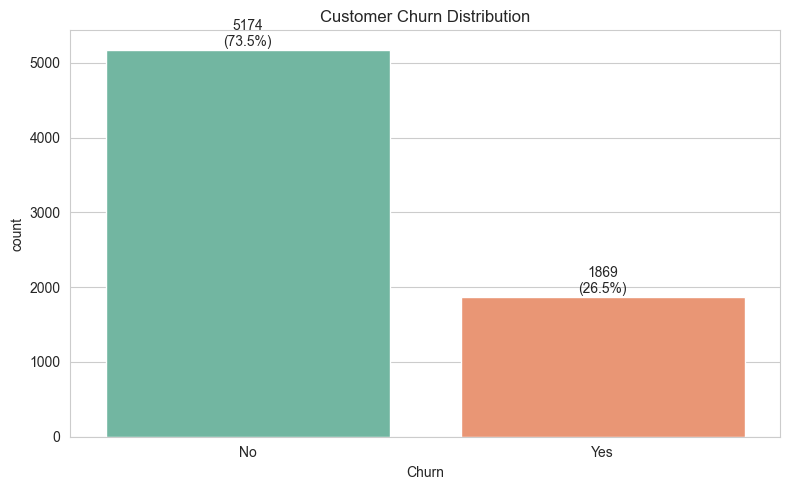

In [28]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots()
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False, ax=ax)
ax.set_title('Customer Churn Distribution')
for i, v in enumerate(churn_counts):
    ax.text(i, v + 50, f'{v}\n({churn_pct.iloc[i]:.1f}%)', ha='center')
plt.tight_layout()
plt.savefig('residencydeliverable1_07242026/churn_distribution.png', dpi=120)
plt.show()

### 4.2 Numerical feature distributions

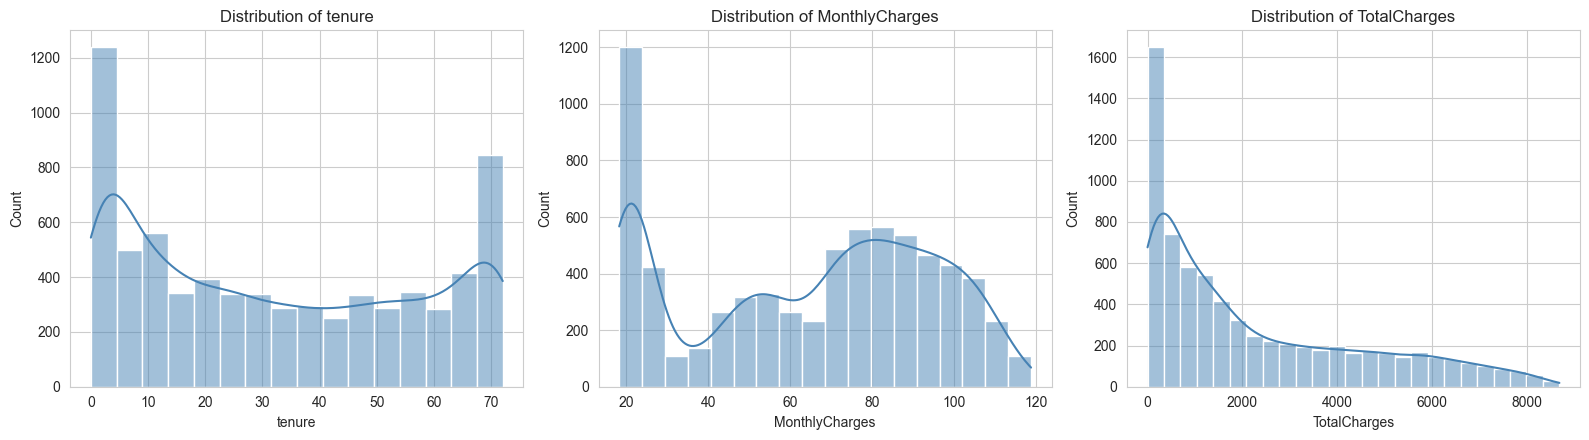

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('residencydeliverable1_07242026/numeric_distributions.png', dpi=120)
plt.show()

### 4.3 Outlier check via boxplots

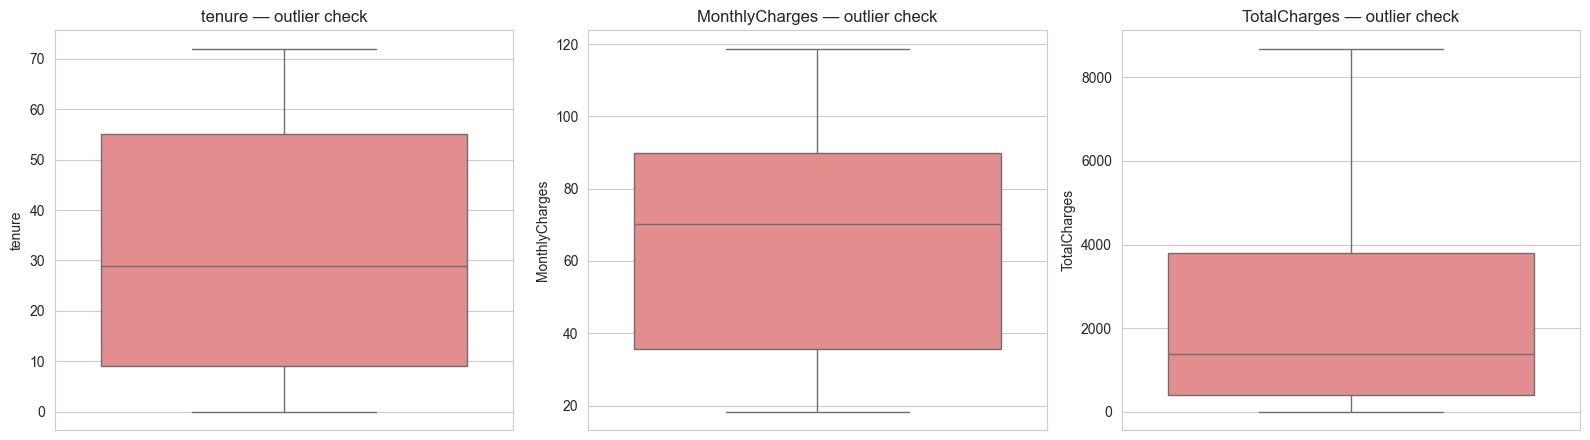

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(f'{col} — outlier check')
plt.tight_layout()
plt.savefig('residencydeliverable1_07242026/boxplots_outliers.png', dpi=120)
plt.show()

**Insight:** None of the three continuous variables show extreme outliers requiring removal — all values fall within the natural, explainable bounds of the business (tenure capped at 72 months, charges scale consistently with services and tenure).

### 4.4 Churn rate by key categorical attributes

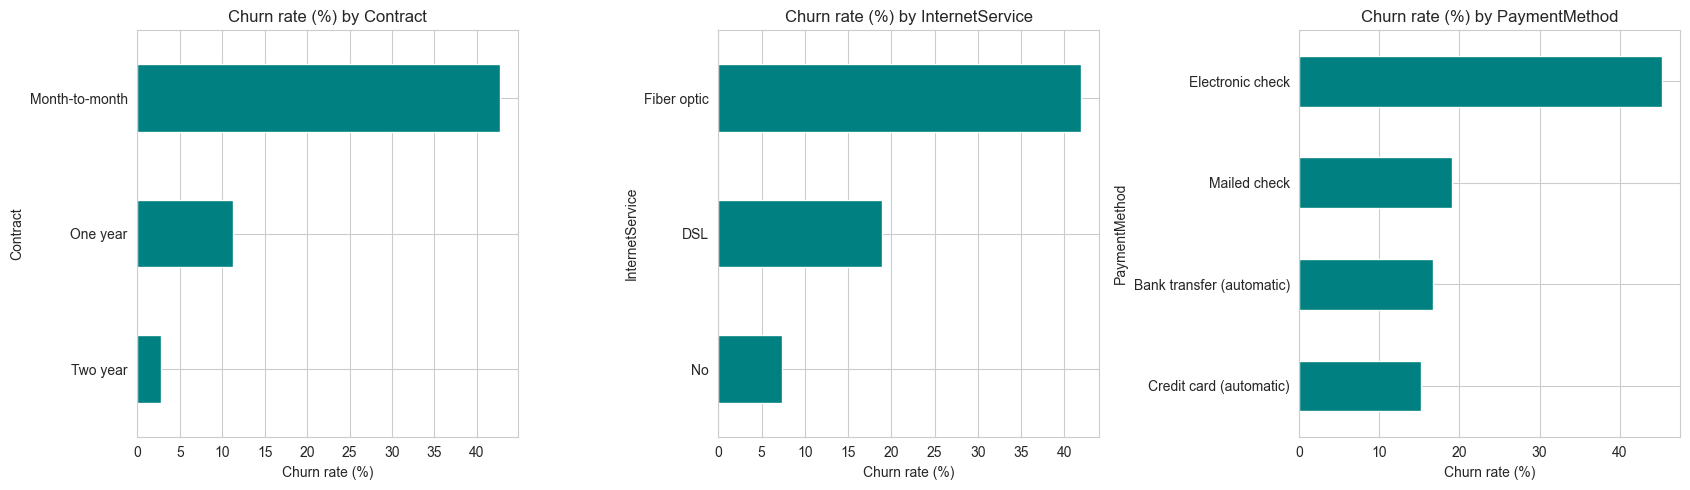

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col in zip(axes, ['Contract', 'InternetService', 'PaymentMethod']):
    churn_rate = df.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100).sort_values()
    churn_rate.plot(kind='barh', ax=ax, color='teal')
    ax.set_title(f'Churn rate (%) by {col}')
    ax.set_xlabel('Churn rate (%)')
plt.tight_layout()
plt.savefig('residencydeliverable1_07242026/churn_by_category.png', dpi=120)
plt.show()

**Insight:** Contract type shows the strongest relationship with churn — month-to-month customers churn at a far higher rate than one- or two-year contract holders. Fiber-optic internet customers and those paying by electronic check also show elevated churn, hinting these may be strong predictors for Deliverable 3's classification models.

### 4.5 Correlation among numeric features

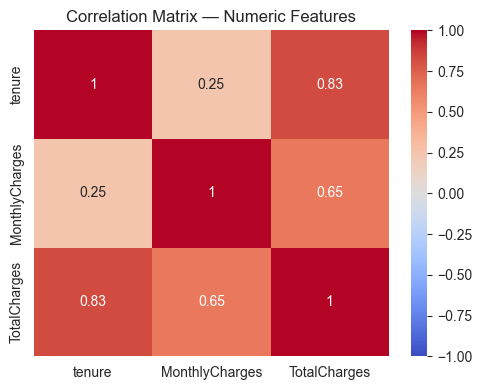

In [32]:
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig('residencydeliverable1_07242026/correlation_heatmap.png', dpi=120)
plt.show()

**Insight:** `TotalCharges` is strongly correlated with both `tenure` (r ≈ 0.83) and `MonthlyCharges` (r ≈ 0.65), which makes sense mechanically (TotalCharges accumulates over tenure at the monthly rate). This multicollinearity is an important consideration for Deliverable 2's regression models — including all three as predictors of one another would be redundant.

## 5. Summary of EDA Insights and Path Forward

1. Class imbalance in the churn target (~26.5% positive) will shape evaluation-metric choice in Deliverable 3.
2. Contract type, internet service, and payment method show visibly different churn rates and are promising classification features.
3. Tenure is bimodal, suggesting two customer lifecycle segments — a good candidate signal for the clustering task in Deliverable 3.
4. TotalCharges is collinear with tenure and MonthlyCharges — Deliverable 2's regression modeling will need to treat this carefully (e.g., predicting MonthlyCharges from service/contract attributes rather than from TotalCharges directly).
5. The cleaned dataset (0 nulls, 0 duplicates, consistent categorical encoding) is now ready for feature engineering and modeling.


In [33]:
df.to_csv('residencydeliverable1_07242026/telco_cleaned.csv', index=False)